In [2]:
import torch 
import lightning as pl
from contrail_segmentation.models.masked_unet import PatchMasker, Masker, MaskedUNET
from segmentation_models_pytorch import Unet
from functools import partial
from hydra.utils import instantiate
import yaml

In [4]:
x = torch.randn((8, 3, 256, 256))
masker = Masker()


In [6]:
masker(x).mean(dim=(1, 2)).mean()

tensor(0.4974, grad_fn=<MeanBackward0>)

In [7]:
model = MaskedUNET.load_from_checkpoint(
    '../checkpoints/masked_resnet50_best-contrail_seed0-v1.ckpt', weights_only=False
)

In [3]:
import numpy as np
import goes2go as goes
import pandas as pd
import matplotlib.pyplot as plt
import os
import random

from matplotlib import animation
from IPython import display

data_dir = '../data/train'
meta_path = '../data/train_metadata.csv'
metadata = pd.read_csv(meta_path)

In [4]:
def get_band_images(idx: str, parent_folder: str, band: str):
    idx = str(idx)
    return np.load(os.path.join(parent_folder, idx, f'band_{band}.npy'))

def get_mask(idx: str, parent_folder: str):
    idx = str(idx)
    return np.load(os.path.join(parent_folder, idx, f'human_pixel_masks.npy'))

def get_mask_ind(idx: str, parent_folder: str):
    idx = str(idx)
    return np.load(os.path.join(parent_folder, idx, f'human_individual_masks.npy'))

_T11_BOUNDS = (243, 303)
_CLOUD_TOP_TDIFF_BOUNDS = (-4, 5)
_TDIFF_BOUNDS = (-4, 2)

def normalize_range(data, bounds):
    return (data - bounds[0]) / (bounds[1] - bounds[0])

def fake_color_img(idx, parent_folder, get_mask_frame_only=False):
    
    band11 = get_band_images(idx, parent_folder, '11')
    band14 = get_band_images(idx, parent_folder, '14')
    band15 = get_band_images(idx, parent_folder, '15')
    
    if get_mask_frame_only:
        band11 = band11[:,:,4]
        band14 = band14[:,:,4]
        band15 = band15[:,:,4]

    r = normalize_range(band15 - band14, _TDIFF_BOUNDS)
    g = normalize_range(band14 - band11, _CLOUD_TOP_TDIFF_BOUNDS)
    b = normalize_range(band14, _T11_BOUNDS)
    false_color = np.clip(np.stack([r, g, b], axis=2), 0, 1)
    return false_color

In [ ]:
idx = random.randint(0, len(metadata)-1)
record_id = metadata.loc[idx]['record_id']
example_img = fake_color_img(record_id, data_dir)[:, :, :, 4]

In [ ]:
input_img = torch.from_numpy(example_img).unsqueeze(0).permute(0, 3, 1, 2).to('cuda')
out = model(input_img, return_mask=True)

fig, axes = plt.subplots(1, 5, figsize=(12, 8))
axes[0].imshow(example_img)
axes[0].axis('off')
axes[1].imshow(get_mask(record_id, data_dir))
axes[1].axis('off')
axes[2].imshow(out[0].detach().cpu().numpy().squeeze())
axes[2].axis('off')
im = axes[3].imshow(out[1].detach().cpu().numpy().squeeze(), cmap='gray')
axes[3].axis('off')
axes[4].imshow(out[1].detach().cpu().squeeze().unsqueeze(dim=-1).numpy()* example_img, cmap='gray')
axes[4].axis('off')
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

ValueError: not enough values to unpack (expected 2, got 1)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

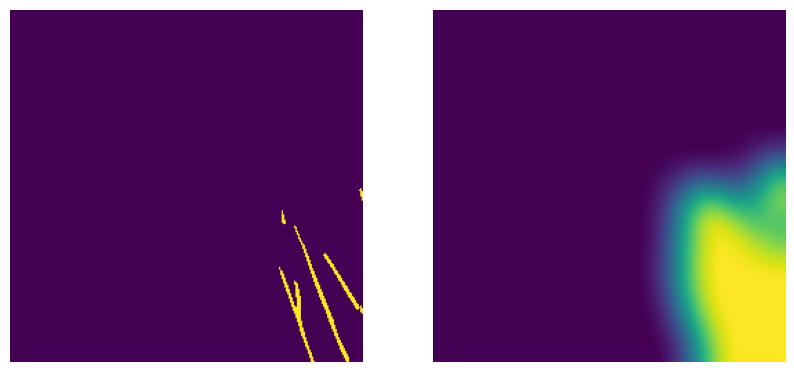

In [58]:
from torchvision.transforms.functional import gaussian_blur
import math

import torch.nn.functional as F

idx = random.randint(0, len(metadata)-1)
record_id = metadata.loc[idx]['record_id']
example_img = fake_color_img(record_id, data_dir)[:, :, :, 4]

def plateau_cloud(mask, dilation_size=25, blur_sigma=30):
    if mask.ndim == 3:
            mask = mask.unsqueeze(1)
            
    padding = dilation_size // 2
    thick_mask = F.max_pool2d(mask.float(), kernel_size=dilation_size, stride=1, padding=padding)
    
    k_size = int(math.ceil(4 * blur_sigma)) | 1 
    soft_targets = gaussian_blur(thick_mask, [k_size, k_size], sigma=[blur_sigma, blur_sigma])
    
    view_shape = soft_targets.shape
    flat_targets = soft_targets.view(view_shape[0], -1)
    max_per_sample = flat_targets.max(dim=1, keepdim=True)[0]
    
    soft_targets = flat_targets / (max_per_sample + 1e-8)
    
    return soft_targets.view(view_shape) 

def get_full_cloud_mask(mask, sigma=25.0, gamma=0.2):
    mask = mask.float()
    
    k_size = int(math.ceil(4 * sigma))
    if k_size % 2 == 0:
        k_size += 1
        
    with torch.no_grad():
        soft_targets = gaussian_blur(mask, [k_size, k_size], sigma=[sigma, sigma])

        max_val = soft_targets.max()
        if max_val > 0:
            soft_targets = soft_targets / max_val

        soft_targets = torch.pow(soft_targets, gamma)
        
    return soft_targets

mask = torch.tensor(get_mask(record_id, data_dir)).unsqueeze(0).permute(0, 3, 1, 2).float()
soft_targets = plateau_cloud(mask, dilation_size=35, blur_sigma=15)
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(mask.squeeze().numpy())
axes[0].axis('off')
axes[1].imshow(soft_targets.squeeze().numpy())
axes[1].axis('off')